<a href="https://colab.research.google.com/github/edgaryoungpilo-web/colab-files/blob/main/Practica_24_266659.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica: Ejercicios sobre Clases No Balanceadas, Data Leakage (Pipeline) y SVM

# 1 Importacion de librerias

In [1]:
# ==========================================
# LIBRERÍAS
# ==========================================

import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y modelado
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Métodos de balanceo
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import OneSidedSelection

# Pipeline con balanceo
from imblearn.pipeline import Pipeline as ImbPipeline

# Configuración visual
sns.set(style='whitegrid')

# 2 Carga del Dataset

In [2]:
# Carga del dataset
df = pd.read_csv('/content/drive/MyDrive/ClassFiles/compustat.csv')

# Mostrar primeras filas
df.head()

,idx,at0,at1,at2,at3,at4,at5,at6,at7,at8,...,at11,at12,at13,at14,at15,at16,at17,at18,at19,label
0,0,0.076753,0.066548,0.132170,4.257882,0.771988,0.669344,0.076278,2.898450,6.081867,...,2.052378,0.372113,0.322636,0.250182,1.153351,0.451476,0.590680,0.512143,0.076278,0
1,1,0.097633,0.087736,0.162879,4.141787,0.781934,0.702665,0.082633,2.947445,6.272092,...,1.968984,0.371728,0.334043,0.231646,1.112813,0.409376,0.593143,0.533012,0.056273,0
2,2,0.025683,0.022020,0.152882,3.140505,0.698522,0.598883,0.097905,2.971928,6.508112,...,1.374306,0.305678,0.262075,0.220100,1.166375,0.487141,0.476098,0.408186,0.050251,0
3,3,0.011354,0.008987,0.165670,2.927575,0.699374,0.553558,0.107831,2.955952,6.588417,...,1.173407,0.280317,0.221873,0.245524,1.263416,0.487903,0.460482,0.364474,0.047244,0
4,4,0.001675,0.001212,0.155509,3.120983,0.689971,0.499122,0.098458,2.896668,6.607998,...,1.069792,0.236504,0.171086,0.271291,1.382369,0.464594,0.468896,0.339197,0.042986,0


# 3 Preparacion de datos

In [3]:
# Preparacion de datos

# El primer atributo es un índice y debe ignorarse
df = df.iloc[:, 1:]

# Variables predictoras
X = df.iloc[:, :-1]

# Etiqueta de clase
y = df.iloc[:, -1]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (13657, 20)
Dimensiones de y: (13657,)


# 4 Analisis de exploratorio de datos (AED)

## 4.1 Distribucion de clases

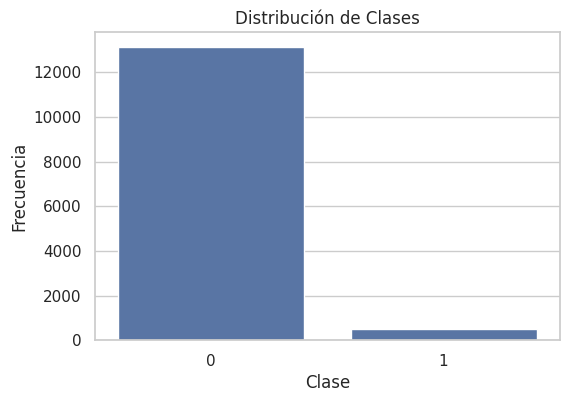

label
0    13137
1      520
Name: count, dtype: int64


In [4]:
#Distribucion de clases

plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title('Distribución de Clases')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')

plt.show()

print(y.value_counts())

## 4.2 Diagramas de KDE para atributos 5 y 13

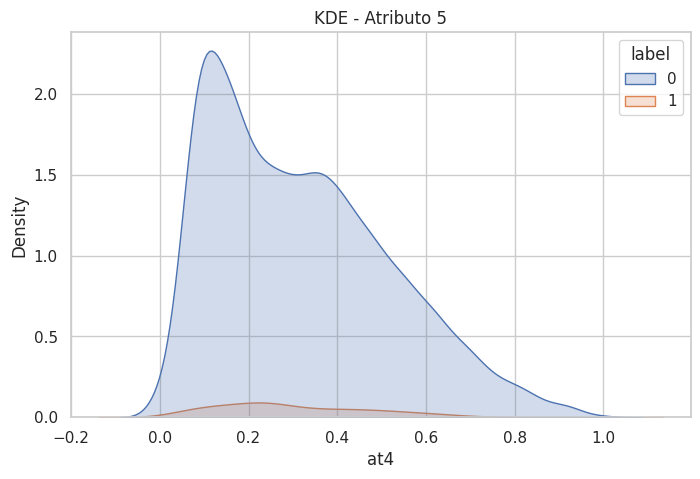

In [5]:
# KDE Atributo 5

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x=df.columns[4],
    hue=y,
    fill=True
)

plt.title('KDE - Atributo 5')
plt.show()

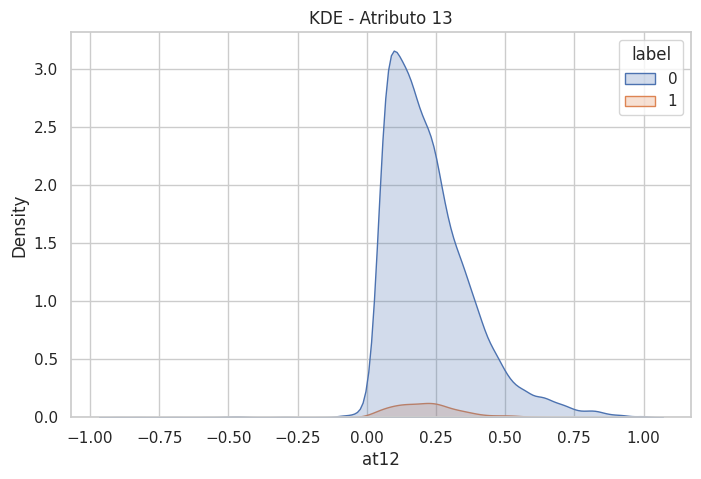

In [6]:
# KDE Atributo 13

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x=df.columns[12],
    hue=y,
    fill=True
)

plt.title('KDE - Atributo 13')
plt.show()

## Analisis

El conjunto de datos presenta el roblema de las clsases no balanceadas, ya que una de las clases tiene mayor muestras respecto a la otra.

Este tipo de desbalance puede provocar que el modelo aprenda a favorecer a la clase mayoritaria, con valores altos de Accuracy con un desempeño deficiente.

Por eso es importante usar tecnicas de balanceo y metricas como Precision, Recall y F1-score.



# 5 Modelo Baseline

In [8]:
# Validacion cruzada

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [9]:
# Pipeline

baseline_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale'
    ))
])

In [10]:
# Predicciones Baseline

y_pred_baseline = cross_val_predict(
    baseline_model,
    X,
    y,
    cv=skf
)

## 5.1 Evaluacion del modelo Baseline

In [11]:
# Metricas Baseline

baseline_accuracy = accuracy_score(y, y_pred_baseline)
baseline_precision = precision_score(y, y_pred_baseline)
baseline_recall = recall_score(y, y_pred_baseline)
baseline_f1 = f1_score(y, y_pred_baseline)

print("Accuracy :", baseline_accuracy)
print("Precision:", baseline_precision)
print("Recall   :", baseline_recall)
print("F1-score :", baseline_f1)

Accuracy : 0.962217178003954
Precision: 1.0
Recall   : 0.007692307692307693
F1-score : 0.015267175572519083


## 5.2 Matriz de confusion

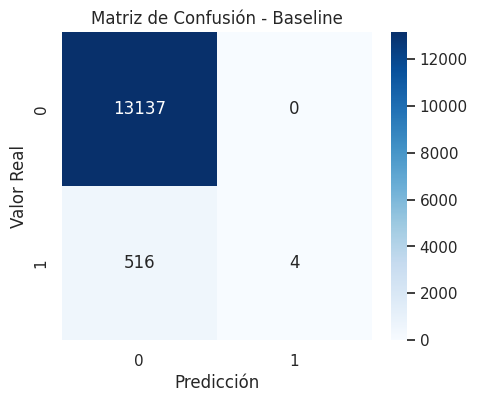

In [12]:
# Matriz de confusion
cm = confusion_matrix(y, y_pred_baseline)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusión - Baseline')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')

plt.show()

# 6 Smoteenn

## 6.1 Pipeline con balanceo

In [17]:
# Pipeline smoteenn

smoteenn_pipeline = ImbPipeline([
    ('smoteenn', SMOTEENN(random_state=42)),
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale'
    ))
])

## 6.2 Predicciones Smoteenn

In [16]:
# Predicciones Smoteenn

y_pred_smoteenn = cross_val_predict(
    smoteenn_pipeline,
    X,
    y,
    cv=skf
)

## 6.3 Evaluacion Smoteenn

In [18]:
# Metricas Smoteenn

smoteenn_accuracy = accuracy_score(y, y_pred_smoteenn)
smoteenn_precision = precision_score(y, y_pred_smoteenn)
smoteenn_recall = recall_score(y, y_pred_smoteenn)
smoteenn_f1 = f1_score(y, y_pred_smoteenn)

print("Accuracy :", smoteenn_accuracy)
print("Precision:", smoteenn_precision)
print("Recall   :", smoteenn_recall)
print("F1-score :", smoteenn_f1)

Accuracy : 0.8119645602987479
Precision: 0.1449375866851595
Recall   : 0.8038461538461539
F1-score : 0.245593419506463


## 6.4 Disribucion despues del smoteenn

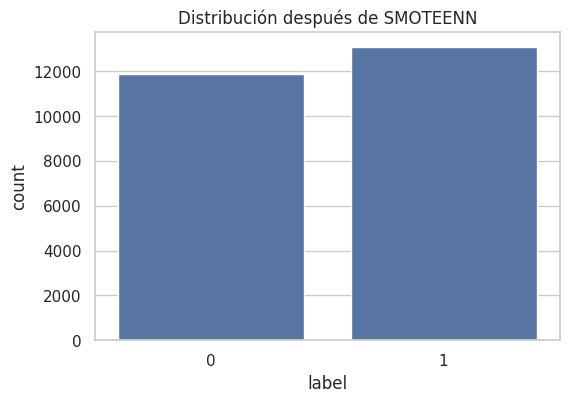

label
1    13080
0    11888
Name: count, dtype: int64


In [19]:
# # Distribucion smoteenn

sm = SMOTEENN(random_state=42)

X_res, y_res = sm.fit_resample(X, y)

plt.figure(figsize=(6,4))

sns.countplot(x=y_res)

plt.title('Distribución después de SMOTEENN')

plt.show()

print(pd.Series(y_res).value_counts())

# 7 One sided selection

## 7.1 Pipeline OSS

In [21]:
# Pipeline OSS

oss_pipeline = ImbPipeline([
    ('oss', OneSidedSelection(random_state=42)),
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale'
    ))
])

## 7.2 Predicciones OSS

In [23]:
# Prediccion OSS

y_pred_oss = cross_val_predict(
    oss_pipeline,
    X,
    y,
    cv=skf
)

## 7.3 Evaluacion OSS

In [24]:
# Metrica OSS

oss_accuracy = accuracy_score(y, y_pred_oss)
oss_precision = precision_score(y, y_pred_oss)
oss_recall = recall_score(y, y_pred_oss)
oss_f1 = f1_score(y, y_pred_oss)

print("Accuracy :", oss_accuracy)
print("Precision:", oss_precision)
print("Recall   :", oss_recall)
print("F1-score :", oss_f1)

Accuracy : 0.962217178003954
Precision: 1.0
Recall   : 0.007692307692307693
F1-score : 0.015267175572519083


## 7.4 Distibucion despues del OSS

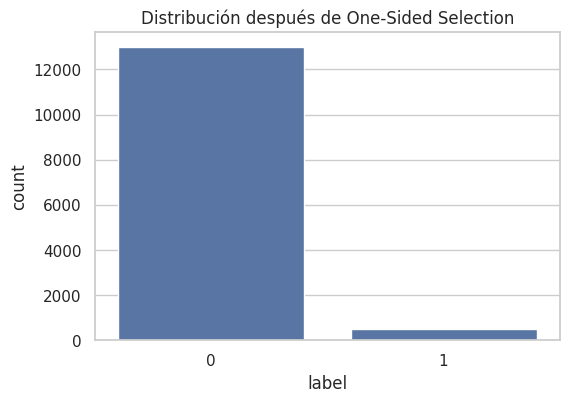

label
0    12994
1      520
Name: count, dtype: int64


In [25]:
# Distribucion

oss = OneSidedSelection(random_state=42)

X_res2, y_res2 = oss.fit_resample(X, y)

plt.figure(figsize=(6,4))

sns.countplot(x=y_res2)

plt.title('Distribución después de One-Sided Selection')

plt.show()

print(pd.Series(y_res2).value_counts())

# 8 Comparacion de resultados

In [26]:
# Tabla de comparacion
results = pd.DataFrame({
    'Modelo': ['Baseline', 'SMOTEENN', 'OSS'],
    'Accuracy': [
        baseline_accuracy,
        smoteenn_accuracy,
        oss_accuracy
    ],
    'Precision': [
        baseline_precision,
        smoteenn_precision,
        oss_precision
    ],
    'Recall': [
        baseline_recall,
        smoteenn_recall,
        oss_recall
    ],
    'F1-score': [
        baseline_f1,
        smoteenn_f1,
        oss_f1
    ]
})

results

,Modelo,Accuracy,Precision,Recall,F1-score
0,Baseline,0.962217,1.000000,0.007692,0.015267
1,SMOTEENN,0.811965,0.144938,0.803846,0.245593
2,OSS,0.962217,1.000000,0.007692,0.015267


# 9 Grafica comparativa

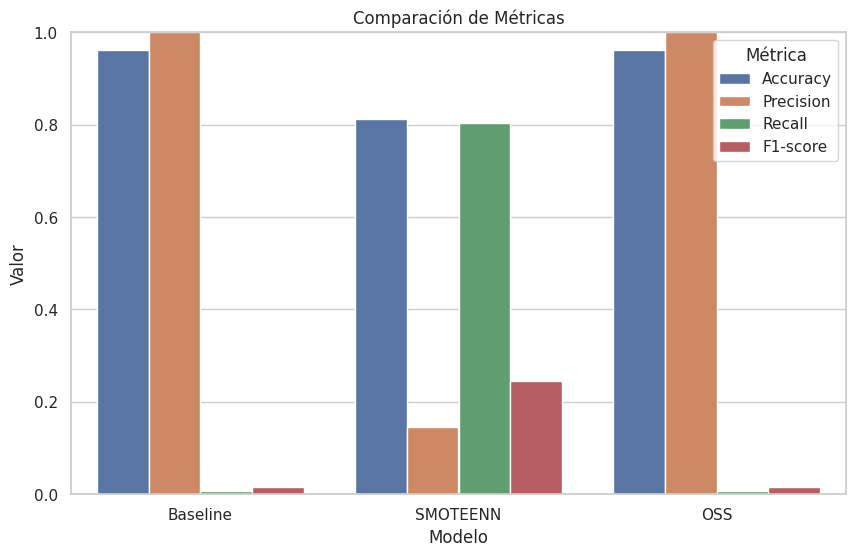

In [27]:
# Grafica comparativa

results_melted = results.melt(
    id_vars='Modelo',
    var_name='Métrica',
    value_name='Valor'
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_melted,
    x='Modelo',
    y='Valor',
    hue='Métrica'
)

plt.title('Comparación de Métricas')
plt.ylim(0,1)

plt.show()

# 10 Discusion sobre Accuracy

El accuracy no es suficiente para la evaluacion de los problemas con clases desbalanceadas, debido a que el odelo puedo obtener una presicon alta global simpemente prediciendo correctamente la clase mayoritaria.

La metrica Recall y F1-score son mas importantes porque perminen la evaluacin de la minoria. Por ello, el uo excluiisvo de accuracy puede conducir a interpretaciones incorrectas.

# 11 Discusion y conclusiones

Impacto del desbalance

El desbalance de clases afecta significativamente el desempeño de los modelos de clasificación. El modelo baseline mostró tendencia a favorecer la clase mayoritaria, reduciendo la capacidad de detección de la clase minoritaria.

Comparación entre SMOTEENN y One-Sided Selection

SMOTEENN combina sobremuestreo y limpieza de datos, lo que permite generar nuevas muestras sintéticas y eliminar ruido. Esto generalmente mejora el Recall y el F1-score.

Por otro lado, One-Sided Selection elimina ejemplos redundantes de la clase mayoritaria, reduciendo el tamaño del conjunto de entrenamiento y mejorando la separación entre clases.

Mejor método

El mejor método dependerá de las métricas obtenidas. Sin embargo, normalmente SMOTEENN suele proporcionar mejores resultados en Recall y F1-score debido a que fortalece la representación de la clase minoritaria.

Conclusión final

Las técnicas de balanceo permiten mejorar considerablemente el desempeño de los modelos de clasificación en problemas desbalanceados. Además, el uso de pipelines y validación cruzada ayuda a evitar data leakage y proporciona una evaluación más confiable del modelo.